# Whisper — quick-start: AT2017GFO with a *custom* model

A hands-on tour of [`whisper_cbpf`](https://github.com/phelipedarc/WHISPER-CBPF) on the kilonova
**AT2017GFO**: load a light curve → inspect → plot → define **your own model** → fit it with ABC →
compare models → (optional) run **SNPE**.

Whisper runs standalone — its data handling, samplers, likelihoods and plots are its own. Physical
models + priors can *optionally* be plugged in from the external **redback** package, but nothing here
needs it.

> Run the cells top to bottom. Inference cells use `n_jobs=1` so they work in any notebook; a
> module-level model function (in a `.py`) can use `n_jobs>1` for parallel ABC.

In [1]:
import warnings
warnings.filterwarnings("ignore")           # keep the tutorial output readable

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__)
print("samplers:", wp.list_samplers())
print("built-in models:", wp.list_models())

whisper_cbpf 0.2.0
samplers: ['abc', 'abc_gpu', 'abc_smc', 'abc_smc_gpu', 'dynesty', 'emcee_jax', 'mcmc', 'nested', 'npe', 'nuts_gpu', 'pymc_jax_gpu_parallelized', 'pymc_jax_gpu_vectorized', 'snpe', 'snpe_gpu']
built-in models: ['bazin', 'flare', 'flare_jax', 'gaussian_rise', 'mck19', 'two_component_kilonova']


## 1. Load the light curve

`load_lightcurve` auto-detects the columns (time / magnitude or flux / band / errors), normalizes band
names, applies quality cuts, and resolves each band's effective wavelength + zero point. AT2017GFO sits
in NGC 4993 at redshift **z ≈ 0.0098**.

In [2]:
csv = next(p for p in [Path("../tests/data/at2017gfo.csv"),
                       Path("tests/data/at2017gfo.csv"),
                       Path("whisper-cbpf/tests/data/at2017gfo.csv")] if p.exists())

lc = wp.load_lightcurve(csv, redshift=0.0098)
print(lc)
print("n_bands:", len(lc.bands), "| data_mode:", lc.data_mode, "| redshift_known:", lc.redshift_known)

       time        band     magnitude      ... lambda_eff zero_point  system
------------------ ---- ------------------ ... ---------- ---------- -------
        57982.9814    i              17.48 ...     7545.0     3631.0      AB
        57982.9902    H              18.26 ...    16620.0     3631.0      AB
     57982.9919907    C            17.3335 ...        nan        nan unknown
         57982.993    r              17.46 ...     6215.0     3631.0      AB
         57982.999   Ks              18.62 ...    21590.0     3631.0      AB
           57983.0    J              17.83 ...    12350.0     3631.0      AB
           57983.0    V              17.35 ...     6215.0     3631.0      AB
           57983.0    z              17.67 ...     8679.0     3631.0      AB
     57983.0014537    W               17.5 ...        nan        nan      AB
57983.003059500006    i 17.480130787100002 ...     7545.0     3631.0      AB
               ...  ...                ... ...        ...        ...     ...

### The light curve as a table

A `LightCurve` *is* an astropy `Table`, so displaying it shows the rows, with each band's resolved
`lambda_eff` and `zero_point` next to the photometry. `lc.add_flux()` fills in flux density from
the per-band zero point, and `lc.snr` gives the signal-to-noise per point.

In [3]:
lc

time,band,magnitude,magnitude_err,lambda_eff,zero_point,system
float64,str5,float64,float64,float64,float64,str7
57982.9814,i,17.48,0.02,7545.0,3631.0,AB
57982.9902,H,18.26,0.15,16620.0,3631.0,AB
57982.9919907,C,17.3335,0.06,nan,nan,unknown
57982.993,r,17.46,0.03,6215.0,3631.0,AB
57982.999,Ks,18.62,0.05,21590.0,3631.0,AB
57983.0,J,17.83,0.15,12350.0,3631.0,AB
57983.0,V,17.35,0.02,6215.0,3631.0,AB
57983.0,z,17.67,0.03,8679.0,3631.0,AB
57983.0014537,W,17.5,0.2,nan,nan,AB


## 2. Plot it

Report layout: apparent magnitude **and** flux density, all bands overlaid.

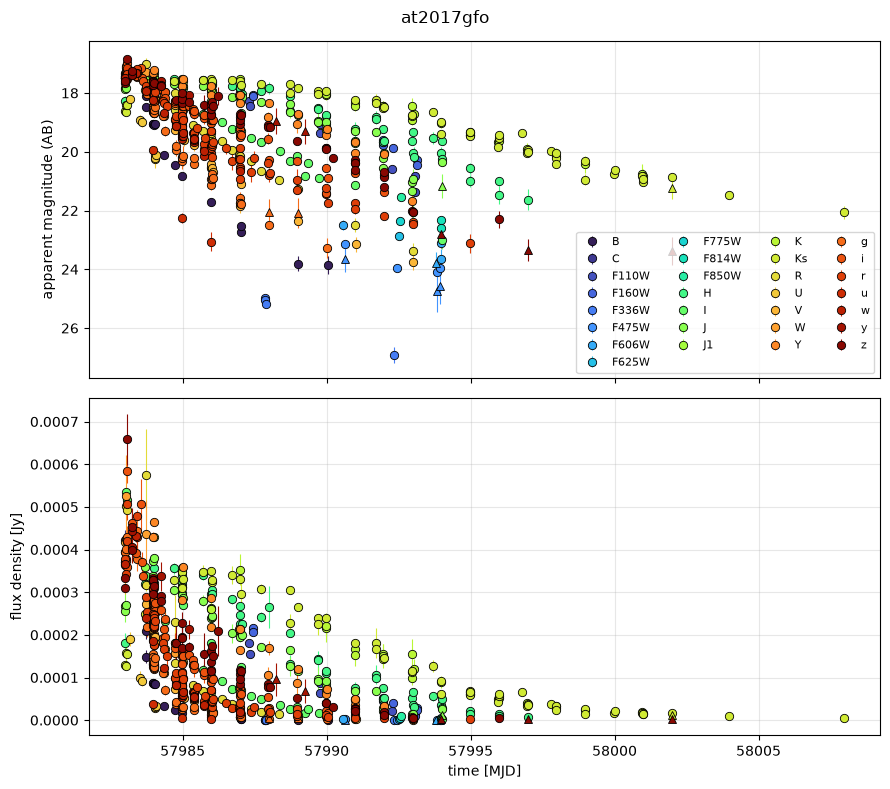

In [4]:
wp.plot_light_curve(lc, layout="report")
plt.show()

## 3. Focus on the r-band, measured from explosion

We set the explosion epoch (MJD 57982 → day 0), keep points with SNR ≥ 3, and select the r-band.

In [5]:
r = (wp.load_lightcurve(csv, redshift=0.0098, explosion_date=57982.0, min_snr=3)
       .select_bands("r"))
print(r.n_points, "r-band points; t =",
      round(float(r.time.min()), 2), "to", round(float(r.time.max()), 2), "days")

88 r-band points; t = 0.99 to 12.97 days


## 4. Define your **own** model

A Whisper model is just a function `predict(params, times, bands) -> flux (Jy)`. Register it once and it
works with **every** sampler. Here we add a *stretched exponential*,

$$ f(t) = A \, \exp\!\left[-\left(t/\tau\right)^{\beta}\right] $$

with a prior on each parameter (`LogUniform` for the positive amplitude scale, `Uniform` otherwise).

In [6]:
def stretched_exp(params, times, bands=None):
    """Custom transient model: A * exp(-(t/tau)**beta), flux in Jy."""
    t = np.clip(np.asarray(times, dtype=float), 0.0, None)
    return params["amplitude"] * np.exp(-(t / params["tau"]) ** params["beta"])

wp.register_model(
    "stretched_exp", stretched_exp, ["amplitude", "tau", "beta"],
    prior=wp.Prior({"amplitude": wp.LogUniform(1e-5, 1e-2),
                    "tau":       wp.Uniform(0.5, 10.0),
                    "beta":      wp.Uniform(0.3, 2.5)}),
    description="A * exp(-(t/tau)^beta)", overwrite=True)

print("models now:", wp.list_models())

models now: ['bazin', 'flare', 'flare_jax', 'gaussian_rise', 'mck19', 'stretched_exp', 'two_component_kilonova']


## 5. Fit the custom model with ABC

Approximate Bayesian Computation: draw parameters from the prior → simulate the light curve → keep the
draws closest to the data. The result carries a posterior summary and model-selection metrics.

In [7]:
res = wp.fit_ABC(r, "stretched_exp", n_simulations=60000, quantile=0.01, n_jobs=1, seed=0)
print(res)
for p, s in res.summary.items():
    print(f"  {p:10s} = {s['median']:.3g}  [{s['ci16']:.3g}, {s['ci84']:.3g}]")

SamplerResult(sampler='abc', model='stretched_exp', n_samples=600, AIC=4389.7, runtime=10.12s)
  amplitude  = 0.000428  [0.000286, 0.000854]
  tau        = 2.54  [1.3, 3.57]
  beta       = 1.18  [0.803, 1.65]


### Plot the fit (best-fit + posterior draws)

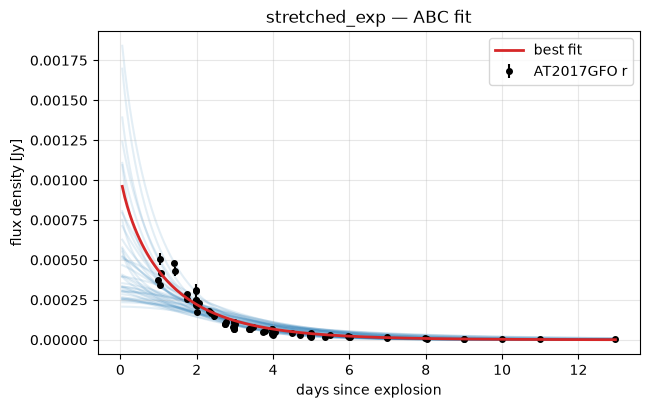

In [8]:
from whisper_cbpf.models import get_model
model = get_model("stretched_exp")
tt = np.linspace(0.05, float(r.time.max()), 200)
rf = r.add_flux()

plt.figure(figsize=(7, 4.2))
plt.errorbar(rf.time, rf.flux, yerr=rf.flux_err, fmt="o", ms=4, color="black", label="AT2017GFO r", zorder=3)
for row in res.samples[res.parameters].sample(n=40, random_state=0).to_numpy():
    plt.plot(tt, model.predict(dict(zip(res.parameters, row)), tt, None), color="C0", alpha=0.12, zorder=1)
plt.plot(tt, model.predict(res.best_params, tt, None), color="C3", lw=2, label="best fit", zorder=4)
plt.xlabel("days since explosion"); plt.ylabel("flux density [Jy]")
plt.title("stretched_exp — ABC fit"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Compare with a built-in model

Fit the built-in `flare` model the same way and compare by AIC / BIC (lower = preferred, on the same
data). This is the core "which model best fits?" question Whisper is built for. `flare`'s shipped
prior is generic (an amplitude up to 10 Jy), so it gets a prior on the same flux scale as
`stretched_exp`'s; otherwise the comparison would be between priors, not models.

In [9]:
flare_prior = wp.Prior({"amplitude":  wp.LogUniform(1e-5, 1e-2),
                        "rise_time":  wp.LogUniform(0.01, 5.0),
                        "decay_time": wp.LogUniform(0.1, 20.0)})
res_flare = wp.fit_ABC(r, "flare", prior=flare_prior, n_simulations=60000, quantile=0.01,
                       n_jobs=1, seed=0)
print(f"{'model':14s} {'AIC':>8s} {'BIC':>8s}")
for rr in (res, res_flare):
    print(f"{rr.model:14s} {rr.aic:8.1f} {rr.bic:8.1f}")

model               AIC      BIC
stretched_exp    4389.7   4397.2
flare            5705.5   5713.0


## 7. (Optional) Neural posterior estimation — SNPE

SNPE trains a neural density estimator instead of using an explicit likelihood. It needs the optional
`[sbi]` extra (`pip install 'whisper-cbpf[sbi]'`) and reuses the **same** model + prior. `num_rounds>1`
focuses simulations sequentially.

 Neural network successfully converged after 223 epochs.

Using NPE_C with atomic loss


 Neural network successfully converged after 83 epochs.

SamplerResult(sampler='snpe', model='stretched_exp', n_samples=4000, AIC=2283.3, runtime=81.29s)


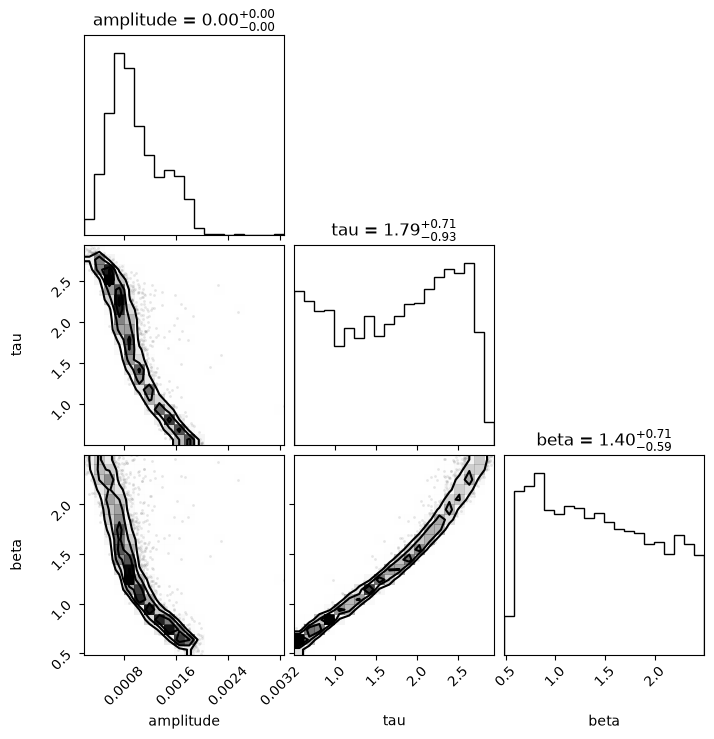

In [10]:
res_snpe = wp.fit_SNPE(r, "stretched_exp", num_rounds=2, num_simulations=1500,
                       num_samples=4000, space="flux", seed=0)
print(res_snpe)

import corner
corner.corner(res_snpe.samples[res_snpe.parameters].to_numpy(),
              labels=res_snpe.parameters, show_titles=True)
plt.show()

For richer, high-dimensional / multi-band problems, `fit_SNPE` also accepts a custom
`embedding_net` (a `torch.nn.Module`), a custom `density_estimator` (or `posterior_nn` hyperparameters
`hidden_features` / `num_transforms` / `num_bins`), and `proposal_mode="restricted"` for **truncated
SNPE**. See `docs/API_REFERENCE.md`.

## Next steps
- Rank several models in one call with `wp.compare`, which also finds each fit's likelihood
  peak and checks its convergence (`notebooks/08_metrics_and_comparison.ipynb`).
- Start from an LSST or ZTF alert: `notebooks/11_lsst_alert_quickstart.ipynb`.
- Try other samplers: `wp.fit_ABC_SMC`, `wp.fit(..., sampler="npe")`.
- Fit multiple bands, add upper limits, or register a physically-motivated model.
- Bring physical models + priors from the optional redback `[models]` extra.
- Full docs: `docs/TUTORIAL.md`, `docs/API_REFERENCE.md`.